# Actividad — Sesión 3: Del dato crudo al dataset listo
### Ingestión y preparación de datos · Inteligencia Artificial (FP13)
**Nombre:** Leonardo Velasco Alvarez **Matrícula:** 5028692  **Fecha:** 06/09/2026

---
### Instrucciones
Trabajas con los **mismos 4 archivos** de la clase (`flota_norteamerica.csv`, `flota_europa.xlsx`,
`flota_asia.txt`, `flota_datalake.parquet`), que deben estar en la **misma carpeta** que este
notebook. Completa cada bloque marcado con `# TODO`. Responde también las **preguntas de análisis**
(celdas de texto). 

**Entrega (hoy mismo):** sube a *Canvas* el link de github a este notebook ejecutado (menú *Kernel → Restart &
Run All* sin errores) con nombre `S3_ApellidoNombre.ipynb`.

**Objetivo:** dejar el dataset **consolidado, limpio y enriquecido** para responder la pregunta:
*¿qué características del powertrain determinan el consumo (L/100 km) de un vehículo?*


## Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

## Parte 1 · Ingestión y consolidación  *(2 pts)*
Lee cada archivo con la función adecuada y únelos en un solo DataFrame `df`.
Recuerda: el TXT usa separador `~` y marca los faltantes con `?`.

In [2]:
# TODO: lee las 4 fuentes
df_xlsx = pd.read_excel('C:/Users/Administrador/Desktop/IA/Practicas_IA/Practicas_parcial_1/Dataset_1/flota_europa.xlsx',sheet_name='registros')
df_csv = pd.read_csv('flota_norteamerica.csv')
df_txt = pd.read_csv('flota_asia.txt',delimiter='~')
df_parquet = pd.read_parquet('flota_datalake.parquet',engine='pyarrow')

# TODO: consolida en un solo DataFrame
df = pd.concat([df_xlsx,df_csv,df_txt,df_parquet], ignore_index = True)

print('Consolidado ->', df.shape)   # se espera (410, 9)

Consolidado -> (410, 9)


## Parte 2 · Limpieza básica  *(2 pts)*
1. Reporta cuántos **duplicados** hay y elimínalos.
2. Reporta cuántos **faltantes** hay en `horsepower` e **imputa** con la mediana.

In [3]:
# TODO: duplicados
print('Duplicados:', df.duplicated().sum())          
df = df.drop_duplicates().reset_index(drop=True)

# TODO: faltantes en horsepower
print('Faltantes horsepower:', df['horsepower'].isnull().sum())
hp_median = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(hp_median)

print('Filas finales:', len(df), '| Faltantes HP:', df['horsepower'].isna().sum())

Duplicados: 12
Faltantes horsepower: 6
Filas finales: 398 | Faltantes HP: 0


## Parte 3 · Mapeos y unidades métricas  *(1.5 pts)*
1. Crea la columna `region` mapeando `origin` (1=EUA, 2=Europa, 3=Japón).
2. Crea `peso_kg` (1 lb = 0.453592 kg).
3. Crea `consumo_L_100km` a partir de `mpg` (fórmula: `235.215 / mpg`).

In [11]:
# TODO: región
df['region'] = df['origin'].map({1: 'EUA', 2: 'Europa', 3: 'Japon'})                # df['origin'].map({...})

# TODO: peso en kg
df['peso_kg'] = (df['weight'] * 0.453592).round(0)             # lb   -> kg

# TODO: consumo en L/100km
df['consumo_L_100km'] = (235.215 / df['mpg']).round(2)      # mpg  -> L/100km

df[['name', 'region', 'peso_kg', 'consumo_L_100km']].head()

,name,region,peso_kg,consumo_L_100km
0,volkswagen 1131 deluxe sedan,Europa,832.0,9.05
1,peugeot 504,Europa,1212.0,9.41
2,audi 100 ls,Europa,1102.0,9.80
3,saab 99e,Europa,1077.0,9.41
4,bmw 2002,Europa,1013.0,9.05


## Parte 4 · Extracción e ingeniería de características  *(2 pts)*
1. Extrae la **marca** (primer token de `name`). Corrige al menos: `chevy`/`chevroelt`→`chevrolet`,
   `toyouta`→`toyota`, `vw`/`vokswagen`→`volkswagen`.
2. Crea la característica `relacion_pot_peso` = `horsepower / peso_kg`.
3. **Diseña tú una característica nueva** con sentido automotriz (por ejemplo, peso por cilindro,
   una bandera `es_importado`, etc.) y explícala en la celda de texto.

In [ ]:
# TODO: marca normalizada
correcciones = {
    'chevroelt': 'chevrolet', 'chevy': 'chevrolet', 'maxda': 'mazda',
    'toyouta': 'toyota', 'vw': 'volkswagen', 'vokswagen': 'volkswagen',
    'mercedes-benz': 'mercedes'
}           
df['marca'] = df['name'].str.split().str[0].replace(correcciones)

# TODO: relación potencia-peso
df['relacion_pot_peso']  = (df['horsepower'] / df['peso_kg']).round(4)

# TODO: relación potencia-peso-consumo
df['relacion_pp_consumo']  = (df['relacion_pot_peso'] / df['consumo_L_100km']).round(4)

# TODO: relación cantidad de cilindros y cilindrada (displacement)
df['cilindrada_por_cilindro'] = (df['displacement'] / df['cylinders']).round(4)

df[['name', 'marca', 'relacion_pot_peso', 'relacion_pp_consumo', 'cilindrada_por_cilindro']].head()

,name,marca,relacion_pot_peso,relacion_pp_consumo,cilindrada_por_cilindro
0,volkswagen 1131 deluxe sedan,volkswagen,0.0553,0.0061,24.25
1,peugeot 504,peugeot,0.0718,0.0076,27.50
2,audi 100 ls,audi,0.0817,0.0083,26.75
3,saab 99e,saab,0.0882,0.0094,26.00
4,bmw 2002,bmw,0.1115,0.0123,30.25


**✍️ Explica tu característica nueva** (2–3 líneas: qué mide y por qué podría ayudar a predecir el consumo):

Relación potencia-peso-consumo:
Útil para evaluar cuánta potencia tiene el vehículo en relación con su peso y consumo de combustible.

Relación cantidad de cilindros y cilindrada (displacement):
Útil para conocer la cilindrada promedio correspondiente a cada cilindro del motor.

## Parte 5 · Análisis de correlación  *(2 pts)*
1. Calcula la matriz de correlación de las variables numéricas relevantes.
2. Grafica el **mapa de calor**.
3. Identifica un **par altamente correlacionado** (`|r| > 0.9`) y decide cuál conservar.

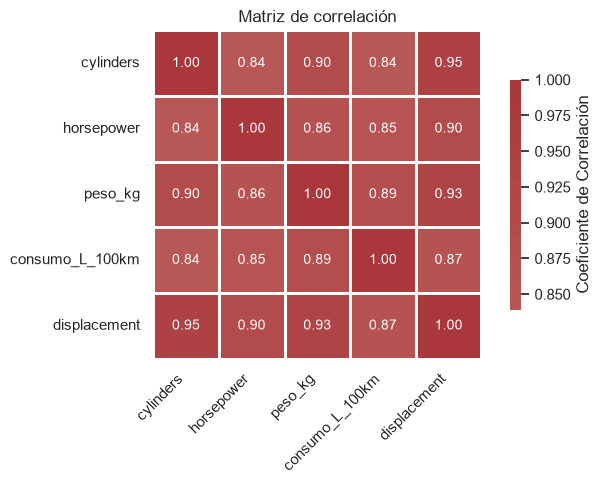

In [30]:
num = ['cylinders', 'horsepower', 'peso_kg', 'consumo_L_100km', 'displacement']   
corr = df[num].corr()
corr.round(2)                     # df[num].corr()

# TODO: mapa de calor con seaborn (usa annot=True, cmap='coolwarm')
plt.figure(figsize=(7, 5))

cmap = sns.diverging_palette(230, 20, as_cmap=True)
 
# 4. Generar el heatmap con los nuevos ajustes
sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap=sns.color_palette("vlag", as_cmap=True),
            center=0,
            square=True, 
            linewidths=1,           # Líneas de separación un poco más gruesas
            linecolor='white',      # Color de separación en blanco para un look limpio
            cbar_kws={'shrink': .7, 'label': 'Coeficiente de Correlación'}, # Etiqueta en la barra derecha
            annot_kws={'size': 10, 'weight': '500'}) # Números más legibles

plt.title('Matriz de correlación')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

**✍️ Pregunta de análisis:** menciona **un par** de variables con `|r| > 0.9`, indica cuál
**eliminarías** y **justifica** por qué (2–3 líneas):

displacement aporta mejor información porque indica de forma más precisa el tamaño o volumen del motor, lo cual sería más relevante a la hora de analizar el carro o comparar variables como si influye la cilindrada con los caballos de fuerza que da y cylinders solo indica cuántos cilindros tiene lo cual no es tan relacionable.

## Cierre  *(reporte, 0.5 pts)*
Muestra la forma final del dataset y sus columnas.

In [31]:
print('Dataset final:', df.shape)
print('Columnas:', list(df.columns))
df.head()

Dataset final: (398, 17)
Columnas: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name', 'region', 'peso_kg', 'consumo_L_100km', 'marca', 'relacion_pot_peso', 'relacion_pot_consumo', 'relacion_pp_consumo', 'cilindrada_por_cilindro']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,region,peso_kg,consumo_L_100km,marca,relacion_pot_peso,relacion_pot_consumo,relacion_pp_consumo,cilindrada_por_cilindro
0,26.0,4,97.0,46.0,1835,20.5,70,2,volkswagen 1131 deluxe sedan,Europa,832.0,9.05,volkswagen,0.0553,0.0061,0.0061,24.25
1,25.0,4,110.0,87.0,2672,17.5,70,2,peugeot 504,Europa,1212.0,9.41,peugeot,0.0718,0.0076,0.0076,27.50
2,24.0,4,107.0,90.0,2430,14.5,70,2,audi 100 ls,Europa,1102.0,9.80,audi,0.0817,0.0083,0.0083,26.75
3,25.0,4,104.0,95.0,2375,17.5,70,2,saab 99e,Europa,1077.0,9.41,saab,0.0882,0.0094,0.0094,26.00
4,26.0,4,121.0,113.0,2234,12.5,70,2,bmw 2002,Europa,1013.0,9.05,bmw,0.1115,0.0123,0.0123,30.25


---
### Rúbrica (10 pts)
| Parte | Criterio | Pts |
|---|---|---|
| 1 | Lee los 4 formatos correctamente y consolida (410 filas) | 2.0 |
| 2 | Elimina 12 duplicados e imputa faltantes con mediana | 2.0 |
| 3 | Mapeos de región y conversiones métricas correctas | 1.5 |
| 4 | Marca normalizada + feature propia con justificación | 2.0 |
| 5 | Heatmap correcto + par redundante bien justificado | 2.0 |
| Cierre | Notebook corre completo sin errores (*Run All*) | 0.5 |
| | **Total** | **10** |

<br>

> Se evalúa que el notebook **corra de principio a fin sin errores** y que las **respuestas de
> análisis** estén redactadas con criterio de ingeniería.
